In [64]:
#Imports
from qiskit import *
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from math import pi
%matplotlib inline

In [65]:
#Circuit Build
q0 = QuantumRegister(1, name="q0")  #Final Qubit
q1 = QuantumRegister(1, name="q1")  #Median Qubit
q2 = QuantumRegister(1, name="q2")  #Initial Qubit

c0 = ClassicalRegister(1, name="c0")

circuit = QuantumCircuit(q0, q1, q2, c0)

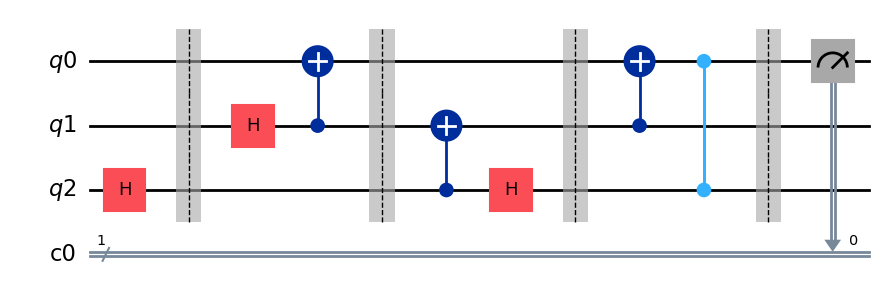

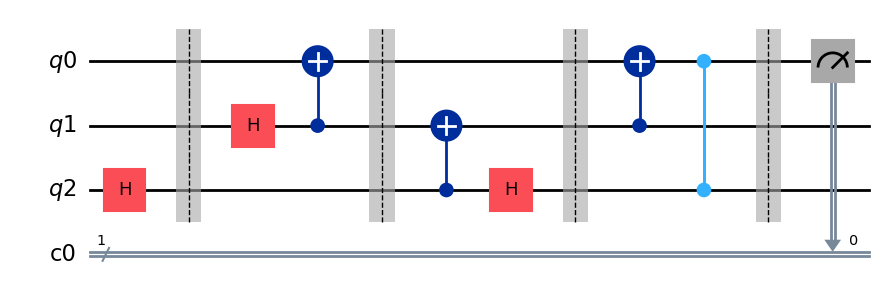

In [66]:
#Gates
circuit.h(q2)
circuit.barrier()

circuit.h(q1)
circuit.cx(q1, q0) #Entangled
circuit.barrier()

circuit.cx(q2, q1)
circuit.h(q2)      #Unentangled
circuit.barrier()

circuit.cx(q1, q0)
circuit.cz(q2, q0)
circuit.barrier()

circuit.measure(q0, c0)

circuit.draw(output='mpl')

In [67]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

#NOTE: Uncomment everything out if you want to use an actual quantum computer from IBM

#service = QiskitRuntimeService(channel='ibm_quantum_platform', token='1I4wWSiaZGqcPeONfFmdDIZ9YnXV538OTasiaDi44Gur')

In [68]:
#qcomp = service.least_busy(operational=True, simulator=False) # select least busy quantum computer

#pm = generate_preset_pass_manager(backend=qcomp, optimization_level=1) # optimize the circuit for quantum execution
#sa_circuit = pm.run(circuit) # modify circuit for qcomp's specific Instruction Set Architecture (ISA)

#sampler = Sampler(qcomp)
#job = sampler.run([isa_circuit])
#result = job.result()
#plot_histogram(result[0].data.c0.get_counts())